In [1]:
import pandas as pd
from pathlib import Path
from pycaret.classification import *

In [2]:
data = pd.read_csv("data/procdata/TCIA_RADCURE_windowed/features/pyradiomics/original_512_512_n/labelled/choi_opc_hpv_2020_hpv_status/TRAIN/original_full_labelled_features.csv", index_col=0)

# All Features

In [3]:
s = setup(data, target = 'hpv_status', session_id=10, data_split_stratify=True, fold=5, n_jobs=-1, experiment_name="RADCURE_HPV")

,Description,Value
0,Session id,10
1,Target,hpv_status
2,Target type,Binary
3,Original data shape,"(617, 10)"
4,Transformed data shape,"(617, 10)"
5,Transformed train set shape,"(431, 10)"
6,Transformed test set shape,"(186, 10)"
7,Numeric features,9
8,Preprocess,True
9,Imputation type,simple


In [4]:
best = compare_models()

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,21:00:52
Status,. . . . . . . . . . . . . . . . . .,Fitting 5 Folds
Estimator,. . . . . . . . . . . . . . . . . .,Logistic Regression


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.7379,0.7133,0.9115,0.7641,0.8312,0.2656,0.2871,0.0100
lr,Logistic Regression,0.7193,0.7030,0.9475,0.7335,0.8268,0.1446,0.1890,0.7020
gbc,Gradient Boosting Classifier,0.7171,0.6695,0.8787,0.7600,0.8146,0.2297,0.2405,0.0540
ridge,Ridge Classifier,0.7147,0.7062,0.9311,0.7358,0.8220,0.1502,0.1811,0.0120
nb,Naive Bayes,0.7101,0.6757,0.8918,0.7490,0.8132,0.1832,0.1988,0.0100
qda,Quadratic Discriminant Analysis,0.7101,0.6731,0.8525,0.7655,0.8059,0.2359,0.2432,0.0120
dummy,Dummy Classifier,0.7077,0.5000,1.0000,0.7077,0.8288,0.0000,0.0000,0.0080
rf,Random Forest Classifier,0.7054,0.6690,0.8623,0.7562,0.8053,0.2089,0.2187,0.0600
lightgbm,Light Gradient Boosting Machine,0.7033,0.6475,0.8426,0.7617,0.7997,0.2285,0.2362,27.8940
et,Extra Trees Classifier,0.6938,0.6722,0.8820,0.7373,0.8029,0.1395,0.1517,0.0520


In [5]:
best

LinearDiscriminantAnalysis(covariance_estimator=None, n_components=None,
                           priors=None, shrinkage=None, solver='svd',
                           store_covariance=False, tol=0.0001)

In [6]:
save_model(best, 'data/procdata/models/RADCURE_windowed_choi_opc_hpv_2020')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['original_shape_Flatness',
                                              'original_shape_SphericalDisproportion',
                                              'wavelet-HLH_firstorder_Mean',
                                              'wavelet-HLH_firstorder_Uniformity',
                                              'wavelet-HLH_glcm_ClusterShade',
                                              'wavelet-LHH_glcm_Idm',
                                              'wavelet-LHH_glcm_Imc1',
                                              'wavelet-LHL_glszm_SmallAreaHigh...
                                                               missing_values=nan,
                                                               strategy='most_frequent'))),
                 ('clean_column_names',
                  TransformerWrap

### Evaluate model on test data

In [33]:
dataset = "TCIA_HEAD-NECK-RADIOMICS-HN1_windowed"
features_dir = Path(f"data/procdata/{dataset}/features/pyradiomics/original_512_512_n/labelled/choi_opc_hpv_2020_hpv_status")
feature_file_list = sorted(features_dir.glob("*labelled_features.csv"))

predictions = pd.DataFrame(columns=['Model', 'Accuracy', 'AUC', 'Recall', 'Prec.', 'F1', 'Kappa', 'MCC'])
for file in feature_file_list:
    test_data = pd.read_csv(file, index_col=0)
    print(file.name.removesuffix('_labelled_features.csv'))
    test_pred = predict_model(best, data=test_data)
    # test_pred['Model'] = file.name.removesuffix('labelled_features.csv')

    # predictions = pd.concat([predictions, test_pred], axis=1)
    

original_full


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Linear Discriminant Analysis,0.2750,0.6415,0.9565,0.2785,0.4314,-0.0252,-0.1771


randomized_full


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Linear Discriminant Analysis,0.3000,0.5515,1.0000,0.2911,0.4510,0.0102,0.0715


randomized_non_roi


...

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Linear Discriminant Analysis,0.2875,0.5942,1.0000,0.2875,0.4466,0.0000,0.0000


shuffled_non_roi


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Linear Discriminant Analysis,0.2875,0.6331,1.0000,0.2875,0.4466,0.0000,0.0000


shuffled_roi


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Linear Discriminant Analysis,0.2875,0.5629,1.0000,0.2875,0.4466,0.0000,0.0000


# Original Features Only

In [3]:
original_features = data.filter(regex='^original_|HPV_bin')

original_setup = setup(original_features, 
                       target = 'HPV_bin', 
                       session_id=10, 
                       data_split_stratify=True, 
                       fold=5, 
                       n_jobs=6, 
                       experiment_name="RADCURE_HPV_original_features")

,Description,Value
0,Session id,10
1,Target,HPV_bin
2,Target type,Binary
3,Original data shape,"(418, 110)"
4,Transformed data shape,"(418, 110)"
5,Transformed train set shape,"(292, 110)"
6,Transformed test set shape,"(126, 110)"
7,Numeric features,109
8,Preprocess,True
9,Imputation type,simple


In [5]:
original_best = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.7741,0.7275,0.9139,0.8113,0.8594,0.2919,0.3083,0.5520
et,Extra Trees Classifier,0.7670,0.6910,0.9410,0.7910,0.8594,0.2046,0.2311,0.2180
dummy,Dummy Classifier,0.7569,0.5000,1.0000,0.7569,0.8616,0.0000,0.0000,0.0340
rf,Random Forest Classifier,0.7568,0.7418,0.9410,0.7819,0.8540,0.1567,0.1837,0.2340
lda,Linear Discriminant Analysis,0.7431,0.7096,0.8326,0.8295,0.8308,0.2970,0.2980,0.0400
lr,Logistic Regression,0.7431,0.5957,0.9682,0.7587,0.8506,0.0148,0.0327,1.6540
lightgbm,Light Gradient Boosting Machine,0.7397,0.6817,0.8911,0.7913,0.8381,0.1852,0.1954,28.4900
knn,K Neighbors Classifier,0.7362,0.5538,0.9275,0.7703,0.8413,0.0911,0.1190,1.2700
nb,Naive Bayes,0.7330,0.4699,0.9592,0.7543,0.8444,-0.0185,-0.0356,0.0480
ridge,Ridge Classifier,0.7328,0.6523,0.9139,0.7745,0.8377,0.0989,0.1126,0.0520


# Low Volume correlation

In [4]:
corr_mat = data.corr()

In [ ]:
vol_corrs = corr_mat['original_shape_MeshVolume'] < 0.3

low_vol_corr_data = data.loc[:, vol_corrs]
low_vol_s = setup(low_vol_corr_data, 
                    target = 'HPV_bin', 
                    session_id=10, 
                    data_split_stratify=True, 
                    fold=5, 
                    n_jobs=6, 
                    experiment_name="RADCURE_HPV_low_vol_corr_features")

,Description,Value
0,Session id,10
1,Target,HPV_bin
2,Target type,Binary
3,Original data shape,"(418, 925)"
4,Transformed data shape,"(418, 925)"
5,Transformed train set shape,"(292, 925)"
6,Transformed test set shape,"(126, 925)"
7,Numeric features,924
8,Preprocess,True
9,Imputation type,simple


In [7]:
low_vol_corr_best = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.7877,0.7907,0.9366,0.8118,0.8696,0.3103,0.3370,3.5860
ada,Ada Boost Classifier,0.7811,0.7025,0.8961,0.8307,0.8614,0.3429,0.3472,0.7060
lightgbm,Light Gradient Boosting Machine,0.7809,0.7394,0.9412,0.8031,0.8667,0.2712,0.3012,40.5820
et,Extra Trees Classifier,0.7808,0.7362,0.9545,0.7960,0.8680,0.2486,0.2994,0.2220
rf,Random Forest Classifier,0.7773,0.7429,0.9455,0.7971,0.8647,0.2547,0.3049,0.3220
dummy,Dummy Classifier,0.7569,0.5000,1.0000,0.7569,0.8616,0.0000,0.0000,0.1280
ridge,Ridge Classifier,0.7534,0.5272,0.9864,0.7595,0.8582,0.0204,0.0468,0.1360
dt,Decision Tree Classifier,0.7226,0.6351,0.8054,0.8260,0.8141,0.2600,0.2642,0.2100
knn,K Neighbors Classifier,0.7192,0.6345,0.8915,0.7740,0.8281,0.0800,0.0771,0.6880
lr,Logistic Regression,0.7158,0.5516,0.9184,0.7578,0.8294,-0.0056,-0.0186,1.3140


## Analyze Model

In [ ]:
plot_model(low_vol_corr_best, plot = 'auc')
plot_model(low_vol_corr_best, plot = 'pr')
plot_model(low_vol_corr_best, plot = 'vc')
plot_model(low_vol_corr_best, plot = 'confusion_matrix')

# Choi HPV Features

In [4]:
choi_signature = ['original_shape_Flatness',
    'original_shape_SphericalDisproportion',
    'wavelet-HLH_firstorder_Mean',
    'wavelet-HLH_firstorder_Uniformity',
    'wavelet-HLH_glcm_ClusterShade',
    'wavelet-LHH_glcm_Idm',
    'wavelet-LHH_glcm_Imc1',
    'wavelet-LHL_glszm_SmallAreaHighGrayLevelEmphasis',
    'wavelet-LLH_glcm_Imc2']

choi_features = data.filter(items=choi_signature + ['hpv_status'])

choi_setup = setup(choi_features,
                   target = 'hpv_status',
                   session_id=10, 
                    data_split_stratify=True, 
                    fold=5, 
                    n_jobs=6, 
                    experiment_name="RADCURE_HPV_choi_features"
                   )

,Description,Value
0,Session id,10
1,Target,hpv_status
2,Target type,Binary
3,Original data shape,"(617, 10)"
4,Transformed data shape,"(617, 10)"
5,Transformed train set shape,"(431, 10)"
6,Transformed test set shape,"(186, 10)"
7,Numeric features,9
8,Preprocess,True
9,Imputation type,simple


In [5]:
choi_best = compare_models()

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,15:35:52
Status,. . . . . . . . . . . . . . . . . .,Loading Estimator
Estimator,. . . . . . . . . . . . . . . . . .,Logistic Regression


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.7379,0.7133,0.9115,0.7641,0.8312,0.2656,0.2871,0.0100
lr,Logistic Regression,0.7193,0.7030,0.9475,0.7335,0.8268,0.1446,0.1890,0.4120
gbc,Gradient Boosting Classifier,0.7171,0.6695,0.8787,0.7600,0.8146,0.2297,0.2405,0.0560
ridge,Ridge Classifier,0.7147,0.7062,0.9311,0.7358,0.8220,0.1502,0.1811,0.0140
nb,Naive Bayes,0.7101,0.6757,0.8918,0.7490,0.8132,0.1832,0.1988,0.0120
qda,Quadratic Discriminant Analysis,0.7101,0.6731,0.8525,0.7655,0.8059,0.2359,0.2432,0.0120
dummy,Dummy Classifier,0.7077,0.5000,1.0000,0.7077,0.8288,0.0000,0.0000,0.0080
rf,Random Forest Classifier,0.7054,0.6690,0.8623,0.7562,0.8053,0.2089,0.2187,0.0640
lightgbm,Light Gradient Boosting Machine,0.7033,0.6475,0.8426,0.7617,0.7997,0.2285,0.2362,3.1420
et,Extra Trees Classifier,0.6938,0.6722,0.8820,0.7373,0.8029,0.1395,0.1517,0.0540


## Analyze Model

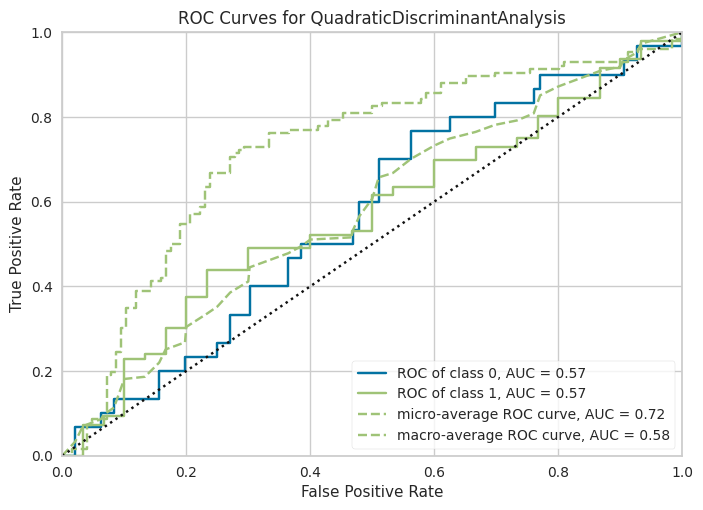

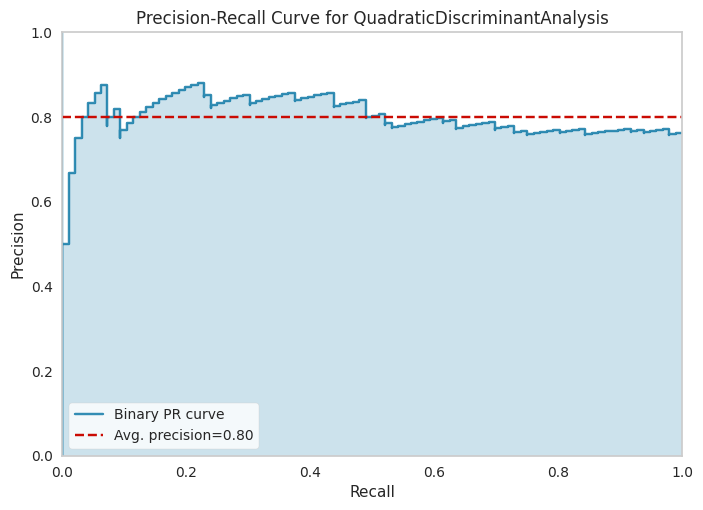

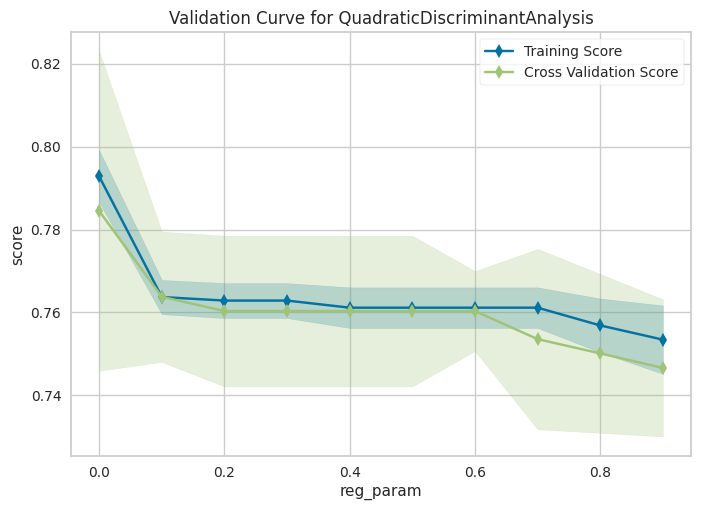

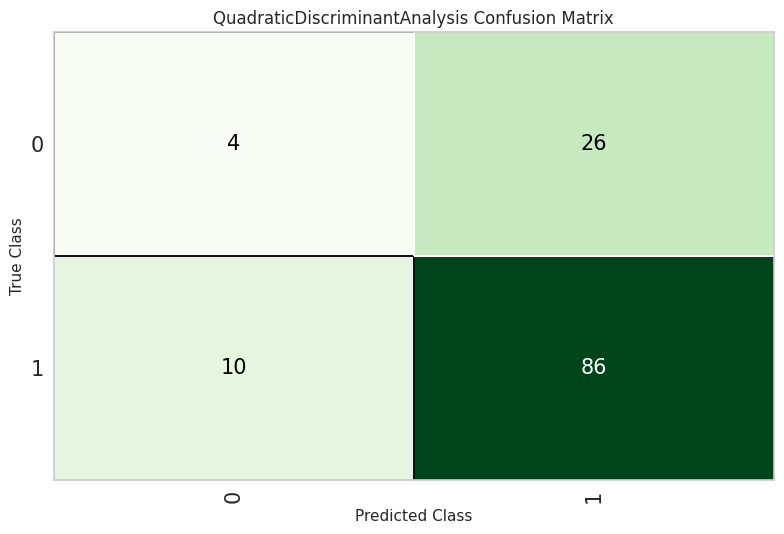

In [33]:
plot_model(choi_best, plot = 'auc')
plot_model(choi_best, plot = 'pr')
plot_model(choi_best, plot = 'vc')
plot_model(choi_best, plot = 'confusion_matrix')

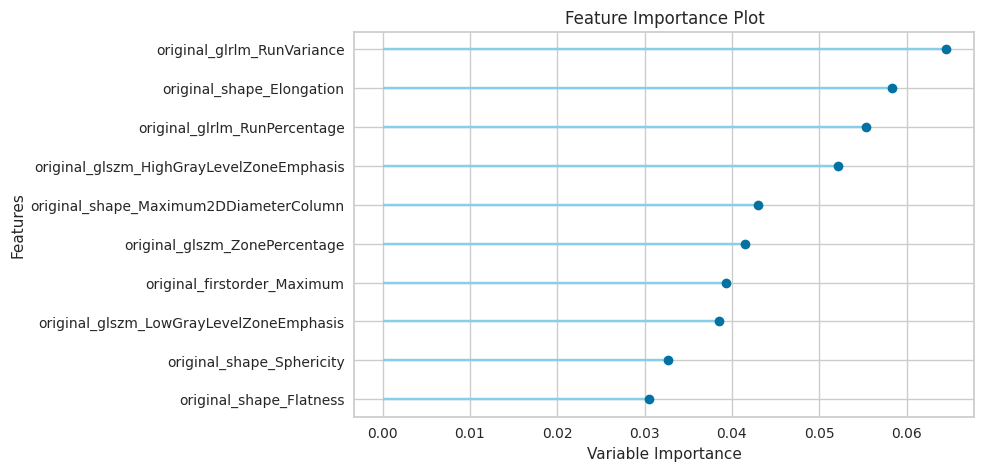

In [9]:
plot_model(original_best, plot= 'feature')

# Test Choi Best model

In [ ]:
test_radcure = pd.read_csv("data/procdata/TCIA_RADCURE_windowed/features/pyradiomics/original_512_512_n/labelled/choi_opc_hpv_2020_hpv_status/TEST/original_full_labelled_features.csv", index_col=0)

test_hn1 = pd.read_csv("data/procdata/TCIA_HEAD-NECK-RADIOMICS-HN1_windowed/features/pyradiomics/original_512_512_n/labelled/choi_opc_hpv_2020_hpv_status/original_full_labelled_features.csv", index_col=0)

LinearDiscriminantAnalysis(covariance_estimator=None, n_components=None,
                           priors=None, shrinkage=None, solver='svd',
                           store_covariance=False, tol=0.0001)

### Evaluate model on test data

In [14]:
dataset = 'RADCURE'

In [15]:
if dataset == 'RADCURE':
    features_dir = Path(f"data/procdata/TCIA_RADCURE_windowed/features/pyradiomics/original_512_512_n/labelled/choi_opc_hpv_2020_hpv_status/TEST")
elif dataset == 'HN1':
    features_dir = Path(f"data/procdata/TCIA_HEAD-NECK-RADIOMICS-HN1_windowed/features/pyradiomics/original_512_512_n/labelled/choi_opc_hpv_2020_hpv_status")

In [16]:
# HN1
feature_file_list = sorted(features_dir.glob("*labelled_features.csv"))

predictions = pd.DataFrame(columns=['Model', 'Accuracy', 'AUC', 'Recall', 'Prec.', 'F1', 'Kappa', 'MCC'])

print(dataset)
for file in feature_file_list:
    test_data = pd.read_csv(file, index_col=0)
    print(file.name.removesuffix('_labelled_features.csv'))
    test_pred = predict_model(choi_best, data=test_data)
    # test_pred['Model'] = file.name.removesuffix('labelled_features.csv')

    # predictions = pd.concat([predictions, test_pred], axis=1)
    

RADCURE
original_full


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Linear Discriminant Analysis,0.7697,0.6724,0.9173,0.8121,0.8615,0.1929,0.2063


randomized_full


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Linear Discriminant Analysis,0.7556,0.4786,0.9676,0.7752,0.8608,-0.0475,-0.0853


randomized_non_roi


...

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Linear Discriminant Analysis,0.7781,0.5669,0.9964,0.7803,0.8752,-0.0056,-0.0281


shuffled_non_roi


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Linear Discriminant Analysis,0.7472,0.5655,0.9209,0.7901,0.8505,0.0623,0.0710


shuffled_roi


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Linear Discriminant Analysis,0.7753,0.6202,0.9928,0.7797,0.8734,-0.0111,-0.0398


In [11]:
feature_file_list

[]